# Notebook 05 — Integration: Speaker-Labeled Transcript

This is the **fifth stage** of the meeting-transcription pipeline.

### What this notebook does

| Step | Description | Output |
|------|-------------|--------|
| 1 | Load speaker labels (notebook 03) + ASR transcripts (notebook 04), join on `seg_id` | merged segment table |
| 2 | Handle edge cases — segments present in one file but not the other | coverage report |
| 3 | Sanity check — no overlapping windows, per-speaker turn counts + durations | stats table |
| 4 | Format as a readable timestamped dialogue (one turn per line) | printed transcript |
| 5 | Eyeball check — display a 3-minute window from the middle of the meeting | visual quality check |
| 6 | Save `transcript_labeled.json` for notebook 06 (evaluation) | JSON on disk |

### How the pieces fit together

```
notebooks 01-03  →  output/clustering/segments_labeled.json
                     {seg_id, start, end, duration, speaker_label}

notebook 04      →  output/asr/EN2001a_asr.json
                     {seg_id, start, end, duration, text, words}

this notebook    →  output/integration/transcript_labeled.json
                     {seg_id, start, end, duration, speaker_label, text, words}
                     ↓
                 notebook 06 (DER + WER evaluation)
```

### Key design decision — cluster labels vs. speaker names

Notebook 03 assigns anonymous labels (`cluster_0 … cluster_4`).
The real speaker identities (FEO065 etc.) are **not** used here — that mapping is
solved in notebook 06 via the Hungarian algorithm on the DER confusion matrix.
This keeps the pipeline honest: the diarization system never peeks at ground-truth
speaker names.


---
## Step 0 — Setup

All dependencies are already installed from previous notebooks.


In [8]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from collections import Counter

print("Imports OK")


Imports OK


---
## Step 1 — Load Inputs

We load two JSON files:

1. **`output/clustering/segments_labeled.json`** (notebook 03) — one record per VAD segment with the predicted cluster label.
2. **`output/asr/EN2001a_asr.json`** (notebook 04) — same segments with Whisper transcription text and word-level timestamps.

Both files index segments by `seg_id`.  The join is done on this key.

> **Note**: if `EN2001a_asr.json` is missing (notebook 04 save bug — fixed in the updated notebook),
> this cell automatically falls back to `EN2001a_asr_tiny.json` so you can proceed immediately.
> Re-run notebook 04 to generate the corrected base-model file.


In [9]:
# ── Paths ──────────────────────────────────────────────────────────────────────
MEETING_ID   = "EN2001a"
CLUSTER_FILE = Path("output/clustering/segments_labeled.json")
ASR_DIR      = Path("output/asr")
INTEG_OUT    = Path("output/integration")
INTEG_OUT.mkdir(parents=True, exist_ok=True)

# Primary ASR file (whisper-base); fall back to tiny if re-run hasn't happened yet
asr_primary = ASR_DIR / f"{MEETING_ID}_asr.json"
asr_tiny    = ASR_DIR / f"{MEETING_ID}_asr_tiny.json"

if asr_primary.exists():
    ASR_FILE = asr_primary
else:
    ASR_FILE = asr_tiny
    print("WARNING: EN2001a_asr.json not found — using tiny fallback.")
    print("         Re-run notebook 04 (save bug is now fixed) to get base-model output.\n")

# ── Load clustering output ─────────────────────────────────────────────────────
with open(CLUSTER_FILE) as fh:
    clust_data = json.load(fh)

clust_segs = {s["seg_id"]: s for s in clust_data["segments"]}

print(f"Clustering  : {CLUSTER_FILE.name}")
print(f"  Algorithm : {clust_data['algorithm']}")
print(f"  Clusters  : {clust_data['n_clusters']}  |  Silhouette: {clust_data['silhouette']}  |  ARI: {clust_data['ari']}")
print(f"  Segments  : {len(clust_segs)}")
print(f"  Labels    : {sorted(set(s['speaker_label'] for s in clust_data['segments']))}")

print()

# ── Load ASR output ────────────────────────────────────────────────────────────
with open(ASR_FILE) as fh:
    asr_data = json.load(fh)

asr_segs = {s["seg_id"]: s for s in asr_data["segments"]}

print(f"ASR         : {ASR_FILE.name}")
print(f"  Model     : {asr_data['model']}")
print(f"  Segments  : {len(asr_segs)}")
print(f"  Audio window: {asr_data['segments'][-1]['end']:.0f}s")


Clustering  : segments_labeled.json
  Algorithm : Spectral (cosine kernel)
  Clusters  : 4  |  Silhouette: 0.38739  |  ARI: 0.841986
  Segments  : 1018
  Labels    : ['cluster_0', 'cluster_1', 'cluster_2', 'cluster_3']

ASR         : EN2001a_asr.json
  Model     : whisper-base
  Segments  : 1018
  Audio window: 5125s


---
## Step 2 — Join + Edge-Case Handling

We merge both dictionaries on `seg_id`.  Three cases can arise:

| Case | Cause | Handling |
|------|-------|---------|
| Both present | normal — this is the majority | include in output |
| Clustering only (no ASR) | segment was too short / silent for Whisper | include with `text = ""` |
| ASR only (no clustering) | segment was in a silence gap — dropped from embeddings in nb02 | include with `speaker_label = "unknown"` |

Both edge cases are flagged and printed so you can inspect them.


In [10]:
def join_segments(clust_segs, asr_segs):
    """
    Outer-join clustering labels and ASR transcripts on seg_id.

    Parameters
    ----------
    clust_segs : dict[int, dict]  seg_id → clustering record
    asr_segs   : dict[int, dict]  seg_id → ASR record

    Returns
    -------
    merged     : list[dict]  sorted by start time, one entry per unique seg_id
    stats      : dict        coverage counts
    """
    all_ids = sorted(set(clust_segs) | set(asr_segs))
    merged  = []

    clust_only = []   # seg_ids present in clustering but not ASR
    asr_only   = []   # seg_ids present in ASR but not clustering

    for sid in all_ids:
        c = clust_segs.get(sid)
        a = asr_segs.get(sid)

        if c is not None and a is not None:
            # ── Normal case: both present ─────────────────────────────────────
            entry = {
                "seg_id":       sid,
                "start":        c["start"],
                "end":          c["end"],
                "duration":     c["duration"],
                "speaker_label": c["speaker_label"],
                "text":         a["text"],
                "words":        a.get("words", []),
            }
        elif c is not None:
            # ── Clustering only: no ASR text ──────────────────────────────────
            clust_only.append(sid)
            entry = {
                "seg_id":       sid,
                "start":        c["start"],
                "end":          c["end"],
                "duration":     c["duration"],
                "speaker_label": c["speaker_label"],
                "text":         "",        # placeholder — no transcript available
                "words":        [],
            }
        else:
            # ── ASR only: no speaker label ────────────────────────────────────
            asr_only.append(sid)
            entry = {
                "seg_id":       sid,
                "start":        a["start"],
                "end":          a["end"],
                "duration":     a["duration"],
                "speaker_label": "unknown",  # placeholder — not clustered
                "text":         a["text"],
                "words":        a.get("words", []),
            }

        merged.append(entry)

    # Sort by start time for a clean temporal order
    merged.sort(key=lambda x: x["start"])

    stats = {
        "total":       len(merged),
        "both":        len(merged) - len(clust_only) - len(asr_only),
        "clust_only":  len(clust_only),
        "asr_only":    len(asr_only),
        "clust_only_ids": clust_only,
        "asr_only_ids":   asr_only,
    }
    return merged, stats


merged, join_stats = join_segments(clust_segs, asr_segs)

print(f"Join results")
print(f"  Total segments         : {join_stats['total']}")
print(f"  Both label + transcript: {join_stats['both']}  ({join_stats['both']/join_stats['total']:.1%})")
print(f"  Clustering only (no ASR): {join_stats['clust_only']}")
print(f"  ASR only (no label)     : {join_stats['asr_only']}")

if join_stats["clust_only"]:
    print(f"\n  Clustering-only seg_ids: {join_stats['clust_only_ids'][:10]} ...")
    print("  → These segments had no Whisper output (likely very short or silent).")
    print("  → Kept in output with text='' — notebook 06 will score them as missed words.")

if join_stats["asr_only"]:
    print(f"\n  ASR-only seg_ids: {join_stats['asr_only_ids'][:10]} ...")
    print("  → These segments had no GT speaker overlap — dropped from embeddings in nb02.")
    print("  → Kept in output with speaker_label='unknown'.")


Join results
  Total segments         : 1018
  Both label + transcript: 1018  (100.0%)
  Clustering only (no ASR): 0
  ASR only (no label)     : 0


---
## Step 3 — Sanity Checks

Three checks before we format anything:

1. **No overlapping segments** — VAD should produce non-overlapping windows; any overlap indicates a pipeline bug upstream.
2. **Per-speaker turn counts and durations** — shows which cluster dominates and whether the distribution is plausible.
3. **Timeline coverage** — what fraction of the audio window is covered by speech segments.


Overlap check: PASS — no overlapping segments.

Audio window     : 5125s (85.4 min)
Total speech     : 4072.5s  (79.5% of window)

Speaker label  Turns  Total speech (s) % of speech  Avg turn (s)  Words
    cluster_0    525            2445.5       60.0%          4.66   8702
    cluster_1    228             773.5       19.0%          3.39   2637
    cluster_2     60             154.5        3.8%          2.58    462
    cluster_3    205             699.0       17.2%          3.41   1787


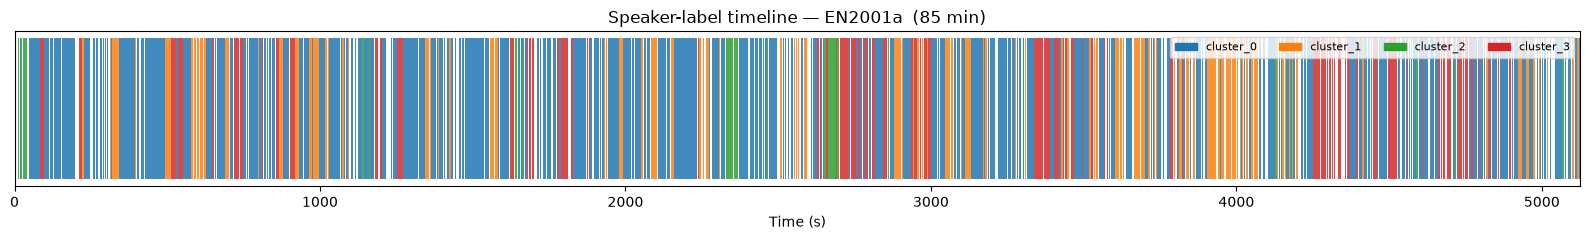

Saved → output/integration/timeline.png


In [11]:
# ── 1. Overlap check ──────────────────────────────────────────────────────────
overlaps = []
for i in range(len(merged) - 1):
    gap = merged[i + 1]["start"] - merged[i]["end"]
    if gap < 0:
        overlaps.append((merged[i]["seg_id"], merged[i + 1]["seg_id"], abs(gap)))

if overlaps:
    print(f"WARNING: {len(overlaps)} overlapping segment pairs found:")
    for a, b, ov in overlaps[:10]:
        print(f"  seg {a} and seg {b} overlap by {ov:.3f}s")
else:
    print("Overlap check: PASS — no overlapping segments.")

# ── 2. Per-speaker (cluster) stats ────────────────────────────────────────────
audio_window_s = merged[-1]["end"]
total_speech_s = sum(s["duration"] for s in merged)

print(f"\nAudio window     : {audio_window_s:.0f}s ({audio_window_s/60:.1f} min)")
print(f"Total speech     : {total_speech_s:.1f}s  ({total_speech_s/audio_window_s:.1%} of window)")
print()

labels = sorted(set(s["speaker_label"] for s in merged))
rows = []
for lbl in labels:
    segs   = [s for s in merged if s["speaker_label"] == lbl]
    dur_s  = sum(s["duration"] for s in segs)
    w_cnt  = sum(len(s["text"].split()) for s in segs)
    rows.append({
        "Speaker label": lbl,
        "Turns": len(segs),
        "Total speech (s)": round(dur_s, 1),
        "% of speech": f"{dur_s/total_speech_s:.1%}",
        "Avg turn (s)": round(dur_s / len(segs), 2),
        "Words": w_cnt,
    })

df_stats = pd.DataFrame(rows)
print(df_stats.to_string(index=False))

# ── 3. Timeline bar chart ─────────────────────────────────────────────────────
_tab10   = plt.colormaps["tab10"]
lbl_pal  = {lbl: _tab10.colors[i] for i, lbl in enumerate(labels)}

fig, ax = plt.subplots(figsize=(16, 2.5))
for seg in merged:
    ax.barh(0, seg["duration"], left=seg["start"],
            color=lbl_pal.get(seg["speaker_label"], "grey"),
            height=0.6, alpha=0.85, linewidth=0)

patches = [mpatches.Patch(color=lbl_pal.get(l, "grey"), label=l) for l in labels]
ax.legend(handles=patches, loc="upper right", fontsize=8, ncol=len(labels))
ax.set_xlabel("Time (s)")
ax.set_title(f"Speaker-label timeline — {MEETING_ID}  ({audio_window_s/60:.0f} min)")
ax.set_yticks([])
ax.set_xlim(0, audio_window_s)
plt.tight_layout()
plt.savefig(INTEG_OUT / "timeline.png", dpi=120)
plt.show()
print("Saved → output/integration/timeline.png")


---
## Step 4 — Format Readable Transcript

Each line: `[MM:SS] cluster_N:  transcript text`

Consecutive turns from the same speaker are merged (collapsed) so the dialogue
reads naturally rather than one line per VAD segment.


In [12]:
def fmt_time(sec):
    """Convert seconds to [MM:SS] string."""
    m = int(sec) // 60
    s = int(sec) % 60
    return f"[{m:02d}:{s:02d}]"


def format_dialogue(segments, collapse=True):
    """
    Return a list of formatted dialogue lines from merged segments.

    Parameters
    ----------
    segments : list[dict]  sorted by start time
    collapse : bool        merge consecutive turns by same speaker

    Returns
    -------
    list[str]  one readable line per (collapsed) turn
    """
    lines = []
    if not segments:
        return lines

    if collapse:
        # Collapse consecutive same-speaker segments into one turn
        turns = []
        cur = {
            "start":   segments[0]["start"],
            "end":     segments[0]["end"],
            "speaker": segments[0]["speaker_label"],
            "texts":   [segments[0]["text"].strip()],
        }
        for seg in segments[1:]:
            if seg["speaker_label"] == cur["speaker"]:
                cur["end"] = seg["end"]
                t = seg["text"].strip()
                if t:
                    cur["texts"].append(t)
            else:
                turns.append(cur)
                cur = {
                    "start":   seg["start"],
                    "end":     seg["end"],
                    "speaker": seg["speaker_label"],
                    "texts":   [seg["text"].strip()],
                }
        turns.append(cur)
    else:
        turns = [
            {
                "start":   s["start"],
                "end":     s["end"],
                "speaker": s["speaker_label"],
                "texts":   [s["text"].strip()],
            }
            for s in segments
        ]

    for t in turns:
        text = " ".join(w for w in t["texts"] if w)
        lines.append(f"{fmt_time(t['start'])} {t['speaker']:12s}  {text}")

    return lines


dialogue_lines = format_dialogue(merged, collapse=True)

print(f"Formatted transcript: {len(dialogue_lines)} turns (from {len(merged)} segments)")
print(f"First 40 lines:\n")
for line in dialogue_lines[:40]:
    print(line)


Formatted transcript: 343 turns (from 1018 segments)
First 40 lines:

[00:10] cluster_2     Does anyone want to see Steve's feedback from there? specification.
[00:16] cluster_0     I drive ready. It's too much more in it than he said yesterday.
[00:21] cluster_2     Not really, so what he's talking about, duplication of it. duplication of effort and stuff and and yeah, seeing that we should maybe think about having a prototype for a weak sex. which isn't next week. Yeah. probably prioritized...
[00:46] cluster_0     You're not safe. if for the prototype features like wherever possible. chunking the stuff that we have pre annotators and stuff. And for this, we don't have pre-annotated, right, like a stupid baseline. Then we should probably be able to, basically, that means we focus on the interface first, so that we take the ready-made parts and just see how we get them work together in the interface the way we wanted. And then we have a working prototype and then we can go back and re

---
## Step 5 — Eyeball Check (3-minute window)

We print the transcript for a 3-minute window centred around the midpoint of the
meeting (~750 s).  This lets you visually verify that:
- speaker labels change at plausible conversation turn-taking points
- transcription text is coherent
- timestamps match the dialogue flow


In [13]:
# ── 3-minute window centred at meeting midpoint ────────────────────────────────
mid = audio_window_s / 2            # ~750 s for a 1500 s window
win_start = mid - 90                # 90 s before midpoint
win_end   = mid + 90                # 90 s after  midpoint

window_segs = [s for s in merged if s["start"] >= win_start and s["end"] <= win_end]
window_lines = format_dialogue(window_segs, collapse=True)

print(f"Eyeball window: {fmt_time(win_start)} – {fmt_time(win_end)}  "
      f"({len(window_segs)} segments, {len(window_lines)} turns)\n")
print("-" * 70)
for line in window_lines:
    print(line)
print("-" * 70)

# Quick per-speaker breakdown for this window
wnd_dur = {lbl: 0.0 for lbl in labels}
for s in window_segs:
    wnd_dur[s["speaker_label"]] = wnd_dur.get(s["speaker_label"], 0.0) + s["duration"]

print("\nSpeaker breakdown in this window:")
for lbl, dur in sorted(wnd_dur.items()):
    bar = "#" * int(dur / 2)
    print(f"  {lbl:12s}  {dur:5.1f}s  {bar}")


Eyeball window: [41:12] – [44:12]  (30 segments, 12 turns)

----------------------------------------------------------------------
[41:34] cluster_0     where I guess you can see something from the data that you have. in your individual ex-mails files that you create. would be nice to have some basic system which is just a place some stuff.
[41:45] cluster_1     So maybe we should try doing something really simple like just displaying a whole meeting. and like just being able to scroll through it or something like that
[41:54] cluster_0     or just adapt like that. Yeah, sort of go from their system and adapt it piece for piece and see how we could... how we could arrange like adapt that to our system. Does anyone want to sit with me and play for 3 hours with Nadex at some point?
[42:17] cluster_1     Are you free after this?
[42:21] cluster_0     I wouldn't like to be, I'd like to go to the gym, I'm theoretically free, but if there's any How about Friday then? Some off all Friday. Giv

---
## Step 6 — Save Output

The output JSON is the input to notebook 06 (evaluation).

**Schema**:
```json
{
  "meeting_id": "EN2001a",
  "audio_window_s": 1500,
  "clustering_algorithm": "Average (cosine)",
  "asr_model": "whisper-base",
  "n_speakers": 5,
  "num_segments": 278,
  "segments": [
    {
      "seg_id": 0,
      "start": 10.6,
      "end": 14.0,
      "duration": 3.4,
      "speaker_label": "cluster_3",
      "text": "...",
      "words": [...]
    }
  ]
}
```


In [14]:
output_payload = {
    "meeting_id":             MEETING_ID,
    "audio_window_s":         round(audio_window_s, 2),
    "clustering_algorithm":   clust_data["algorithm"],
    "asr_model":              asr_data["model"],
    "n_speakers":             clust_data["n_clusters"],
    "num_segments":           len(merged),
    "segments":               merged,
}

out_file = INTEG_OUT / f"{MEETING_ID}_transcript_labeled.json"
with open(out_file, "w", encoding="utf-8") as fh:
    json.dump(output_payload, fh, indent=2, ensure_ascii=False)

size_kb = out_file.stat().st_size / 1e3
print(f"Saved → {out_file}  ({size_kb:.0f} KB)")
print()
print(f"Summary")
print(f"  Meeting          : {MEETING_ID}")
print(f"  Audio window     : {audio_window_s:.0f}s ({audio_window_s/60:.1f} min)")
print(f"  Segments         : {len(merged)}")
print(f"  Dialogue turns   : {len(dialogue_lines)}")
print(f"  Clustering alg.  : {clust_data['algorithm']}")
print(f"  ASR model        : {asr_data['model']}")
print(f"  Speakers (labels): {sorted(set(s['speaker_label'] for s in merged))}")
print()
print("Pipeline stage complete.  Next: notebook 06 (DER + WER evaluation).")


Saved → output/integration/EN2001a_transcript_labeled.json  (1607 KB)

Summary
  Meeting          : EN2001a
  Audio window     : 5125s (85.4 min)
  Segments         : 1018
  Dialogue turns   : 343
  Clustering alg.  : Spectral (cosine kernel)
  ASR model        : whisper-base
  Speakers (labels): ['cluster_0', 'cluster_1', 'cluster_2', 'cluster_3']

Pipeline stage complete.  Next: notebook 06 (DER + WER evaluation).
